# 01 · Which reversible rule works?

Session 13 §16 gives the midpoint rule. The assignment asks which variant worked, so this notebook
tries five ways of moving the residual stream and keeps the one that trains best **and** still gives the
gradient autograd would. The block `f_l` is the same everywhere, `f(p) = a + mlp(ln2(p + a))` with
`a = attn(ln1(p))`, so every variant has exactly the same 21.05M weights.

| rule | forward | how the backward gets the layer input back |
|---|---|---|
| standard | `p[l+1] = p[l] + f(p[l])` | it doesn't: autograd stores every activation |
| **midpoint** (leapfrog) | `p[l+1] = p[l-1] + 2h f(p[l])` | exact: `p[l-1] = p[l+1] - 2h f(p[l])` |
| **euler_fp** | `p[l+1] = p[l] + h f(p[l])` (the standard net) | fixed-point iteration `p <- p[l+1] - h f(p)`, 6 rounds |
| **momentum** (symplectic Euler) | `v += h f(x); x += h v` | exact: `x = x' - h v'`, then `v = v' - h f(x)` |
| **revnet** (additive coupling) | `y1 = x1 + A(x2); y2 = x2 + M(y1)` | exact: `x2 = y2 - M(y1)`, `x1 = y1 - A(x2)` |

"Euler" is the ordinary residual network. It *can* be run backwards, but only by solving
`p = p[l+1] - h f(p)` for `p`, and that iteration converges only while `h f` is a contraction. The screen
checks whether it stays one.

In [1]:
import sys, os, json, pathlib, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not pathlib.Path("ERA_V5").exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/amukka/ERA_V5.git"], check=True)
    os.chdir("ERA_V5/session13_Distributed_Training")
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
if not (ROOT / "data" / "train.bin").exists():          # ~5 minutes: stream FineWeb-Edu, train the BPE
    subprocess.run([sys.executable, "tools/prepare_data.py"], check=True)

import torch, platform
from src import experiments as X
from src.train import pick_device
dev = pick_device()
print("device:", dev, "| torch", torch.__version__, "| python", platform.python_version(), "|", platform.platform())
if dev == "mps":
    print(f"MPS recommended working set: {torch.mps.recommended_max_memory()/2**30:.2f} GiB")
if dev == "cuda":
    print(torch.cuda.get_device_name(), f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB")
print(json.dumps(json.loads((ROOT / "data" / "meta.json").read_text()), indent=1))

device: mps | torch 2.13.0 | python 3.14.5 | macOS-26.6.2-arm64-arm-64bit-Mach-O
MPS recommended working set: 11.84 GiB
{
 "source": "HuggingFaceFW/fineweb-edu, config sample-10BT, streamed in order",
 "vocab_size": 8192,
 "eos_id": 0,
 "train_tokens": 56000000,
 "train_docs": 46080,
 "val_tokens": 1000000,
 "val_docs": 1024,
 "chars_per_token": 3.886,
 "note": "val.bin comes from the tokenizer's training documents; train.bin from the documents after them",
 "seconds": 314.3
}


**The model** (identical in every run): GPT, 10 layers, d_model 384, 6 heads, MLP 4x, sequence 512,
byte-level BPE vocabulary 8,192 with the head tied to the embedding. **21,053,184 parameters**, of which
17,710,848 are outside the embedding tables. No dropout anywhere, because a reversible backward pass
recomputes each block and a random mask would recompute differently. AdamW (0.9, 0.95, wd 0.1), peak LR
1e-3, 3% warmup then cosine to 10%, gradient clip 1.0, fp32.

## 1. The algebra, in float64

Before any training: for each rule, the gradient from the reversible backward (which stores only the
final state) against the gradient autograd computes for the same forward rule (which stores everything).
Tiny model, weights deliberately large (std 0.15) so the blocks are far from the identity.

In [2]:
from tests.test_reversible import check
rows = [check("midpoint", 0.5), check("momentum", 0.5), check("revnet", 1.0),
        check("euler_fp", 1.0, fp_iters=6), check("euler_fp", 1.0, fp_iters=30), check("euler_fp", 0.5, fp_iters=6)]
print(f"{'rule':10s} {'h':>5s}  {'grad rel err':>13s}  {'grad cosine':>12s}  {'max state rebuild err':>22s}")
for r in rows:
    print(f"{r['variant']:10s} {r['h']:5.2f}  {r['grad_rel_err']:13.2e}  {r['grad_cosine']:12.8f}  {r['max_state_rebuild_err']:22.2e}")

rule           h   grad rel err   grad cosine   max state rebuild err
midpoint    0.50       2.06e-13    1.00000000                7.99e-15
momentum    0.50       8.09e-14    1.00000000                8.88e-15
revnet      1.00       7.43e-14    1.00000000                5.88e-15
euler_fp    1.00       8.91e-01    0.45363850                3.08e+00
euler_fp    1.00       8.93e-01    0.45135742                3.67e+00
euler_fp    0.50       8.89e-01    0.45906827                1.31e+00


## 2. The screen: 4M tokens each, batch 32

Same data order, same seed, same schedule (compressed to 4M tokens). Each run ends with the
reversibility check on four held-out rows: the gradient the reversible backward returns against
autograd's, and the rebuilt layer inputs against the ones the forward computed, both at the trained
weights, in fp32 on the GPU.

In [3]:
screen = []
for variant, h in X.SCREEN:
    print(f"\n=== {variant}  h={h} ===")
    s = X.train(name=X.screen_name(variant, h), variant=variant, h=h, batch=X.BASE_BATCH,
                tokens=4_000_000, eval_every=61, eval_batches=20, log_every=10)
    rv = (s["reversibility"] or {}).get("final") or {}
    screen.append({"variant": variant, "h": h, "final_val_loss": s["final_val_loss"],
                   "final_train_loss": s["final_train_loss"], "tok_per_s": s["tok_per_s"],
                   "peak_exact_mib": s["peak_exact_mib"], "diverged_at_step": s["diverged_at_step"],
                   "grad_cosine_final": rv.get("grad_cosine", 1.0),
                   "grad_rel_err_final": rv.get("grad_rel_err", 0.0),
                   "state_rebuild_err_final": rv.get("state_rebuild_rel_err_max", 0.0)})
(X.RESULTS / "screen.json").write_text(json.dumps(screen, indent=2))


=== standard  h=1.0 ===


{"name": "screen_standard_h1", "device": "mps", "config": {"vocab_size": 8192, "seq_len": 512, "n_layer": 10, "n_head": 6, "d_model": 384, "variant": "standard", "h": 1.0, "fp_iters": 6, "extra": {}}, "params": 21053184, "params_non_embedding": 17710848, "batch": 32, "tokens_per_step": 16384, "steps": 244, "peak_lr": 0.001, "warmup": 7, "amp_bf16": 0, "torch": "2.13.0", "machine": "arm64", "processor": "arm"}


step     0/244  tok   0.02M  loss 9.0926  gnorm 6.631  0 tok/s  0.0 min


memory audit at step 3: exact peak 9,372 MiB in aten._log_softmax_backward_data.default


            eval @ 0.98M tokens: val loss 6.7967


...

step   200/244  tok   3.28M  loss 7.1892  gnorm 0.290  4,606 tok/s  12.0 min


step   243/244  tok   3.98M  loss 7.2258  gnorm 0.251  4,569 tok/s  14.6 min


            eval @ 3.98M tokens: val loss 7.2069


reversibility at final weights: grad rel err 9.98e-01, cosine 0.068959, state rebuild err 1.77e+00
{"tok_per_s": 4538.2, "final_train_loss": 7.225827217102051, "final_val_loss": 7.20687096118927, "peak_exact_mib": 2634.7, "peak_alloc_mib": 1610.8, "peak_driver_mib": 11907.1, "train_seconds": 877.3}


2142

In [4]:
print(f"{'rule':9s} {'h':>5s} {'val loss':>9s} {'tok/s':>8s} {'peak MiB':>9s} {'grad cos':>10s} {'grad err':>9s} {'rebuild err':>11s}")
for r in screen:
    print(f"{r['variant']:9s} {r['h']:5.2f} {r['final_val_loss']:9.4f} {r['tok_per_s']:8,.0f} {r['peak_exact_mib']:9,.0f} "
          f"{r['grad_cosine_final']:10.6f} {r['grad_rel_err_final']:9.2e} {r['state_rebuild_err_final']:11.2e}")
best = X.pick_variant(screen)
print("\nchosen for the 50M-token runs:", best["variant"], "h =", best["h"])
(X.RESULTS / "chosen_variant.json").write_text(json.dumps(best, indent=2))

rule          h  val loss    tok/s  peak MiB   grad cos  grad err rebuild err
standard   1.00    6.1731    6,367     9,372   1.000000  0.00e+00    0.00e+00
midpoint   0.50    6.3090    8,555     3,706   1.000000  2.81e-05    5.95e-05
midpoint   0.25    6.3928    8,660     2,800   1.000000  1.19e-05    3.69e-05
momentum   0.50    6.0506    8,539     2,671   1.000000  1.26e-05    2.78e-06
revnet     1.00    6.2115    8,918     2,683   1.000000  3.76e-05    8.90e-07
euler_fp   1.00    7.2069    4,538     2,635   0.068959  9.98e-01    1.77e+00

chosen for the 50M-token runs: momentum h = 0.5


342

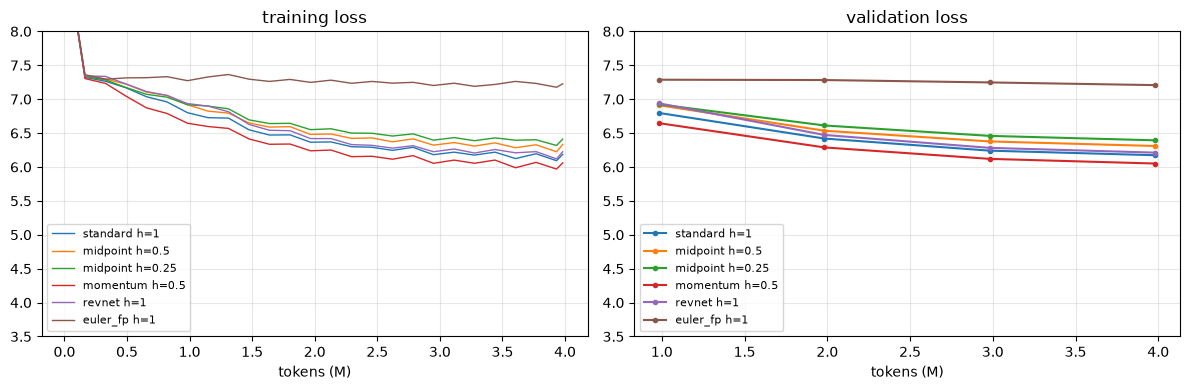

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for variant, h in X.SCREEN:
    log = X.load_log(X.screen_name(variant, h))
    st = [r for r in log if r["type"] == "step"]; ev = [r for r in log if r["type"] == "eval"]
    lab = f"{variant} h={h:g}"
    ax[0].plot([r["tokens"]/1e6 for r in st], [r["loss"] for r in st], label=lab, lw=1)
    ax[1].plot([r["tokens"]/1e6 for r in ev], [r["val_loss"] for r in ev], "o-", label=lab, ms=3)
for a, t in zip(ax, ["training loss", "validation loss"]):
    a.set_xlabel("tokens (M)"); a.set_title(t); a.set_ylim(3.5, 8); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(X.RESULTS / "screen.png", dpi=120); plt.show()